## Setting Up

In [ ]:
# imports & setup
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt


import random

data = pd.read_csv('train_set_80_percent.csv')
data = data.drop(columns=["id", "rank", "player", "hard_hit_95mph+"]) # dropping unnecessary columns
data.shape

(1586, 16)

In [ ]:
# setting fixed seed
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# drop target variable
X = data.drop(columns=["hard_hit_percentage"])
y = data["hard_hit_percentage"]

## Preprocessing and Grid Search

In [ ]:
# preprocessing pipelines

numeric_preprocess = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

# defining random forest regressor
rf = RandomForestRegressor(
    random_state=SEED,
    n_jobs=-1
)

# pipeline to standardaze and run random forest
model = Pipeline(
    steps=[
        ("preprocess", numeric_preprocess),
        ("rf", rf)
    ]
)


# cross validation and hyperparameter grid
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

param_grid = {
    "rf__n_estimators": [100, 300],
    "rf__max_depth": [None, 5, 10],
    "rf__min_samples_split": [2, 5],
    "rf__min_samples_leaf": [1, 2]
}

# We use two metrics: MSE and R^2.
# refit="neg_mse" means the best model is chosen by lowest MSE.
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring={
        "neg_mse": "neg_mean_squared_error",
        "r2": "r2"
    },
    refit="neg_mse",
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)


In [ ]:
# grid search

grid_search.fit(X, y)

print("Random Forest – Best Settings")
print("Best params:", grid_search.best_params_)
print("Best CV neg MSE:", grid_search.best_score_)
print("Best CV MSE:", -grid_search.best_score_)

cv_results = pd.DataFrame(grid_search.cv_results_)

best_row = cv_results.loc[cv_results["rank_test_neg_mse"] == 1].iloc[0]
mean_r2_best = best_row["mean_test_r2"]
std_r2_best = best_row["std_test_r2"]

print(f"Corresponding mean R^2 over CV folds: {mean_r2_best:.4f} ± {std_r2_best:.4f}")


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Random Forest – Best Settings
Best params: {'rf__max_depth': None, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 300}
Best CV neg MSE: -4.156646151402585
Best CV MSE: 4.156646151402585
Corresponding mean R^2 over CV folds: 0.9342 ± 0.0102


## Generating predictions using the best model

In [ ]:
from sklearn.model_selection import cross_val_predict

best_rf_model = grid_search.best_estimator_

y_pred_cv = cross_val_predict(
    best_rf_model,
    X,
    y,
    cv=cv,
    n_jobs=-1
)

mse_cv = mean_squared_error(y, y_pred_cv)
r2_cv = r2_score(y, y_pred_cv)

print("Random Forest – Cross-validated Performance")
print(f"MSE (CV predictions): {mse_cv:.4f}")
print(f"R^2 (CV predictions): {r2_cv:.4f}")

Random Forest – Cross-validated Performance
MSE (CV predictions): 4.1568
R^2 (CV predictions): 0.9348


## True VS Predicted plots

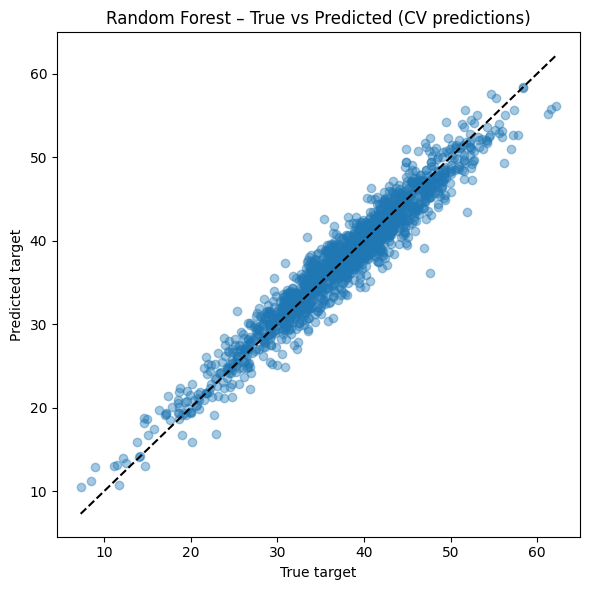

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y, y_pred_cv, alpha=0.4)
plt.xlabel("True target")
plt.ylabel("Predicted target")
plt.title("Random Forest – True vs Predicted (CV predictions)")
min_val = min(y.min(), y_pred_cv.min())
max_val = max(y.max(), y_pred_cv.max())
plt.plot([min_val, max_val], [min_val, max_val], "k--")
plt.tight_layout()
plt.show()